In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import Counter

In [ ]:
### illustration

In [2]:
T_max = 10**3
n_sites_i = 1000
n_sites_f = 2000
n_class = 40

alpha = 1.0

# Générer une distribution de probabilités selon une loi de puissance
ranks = np.arange(1, n_class + 1)
power_law_probs = ranks**(-alpha)
power_law_probs /= power_law_probs.sum()  # Normaliser


In [3]:
power_law_probs

array([0.23372442, 0.11686221, 0.07790814, 0.05843111, 0.04674488,
       0.03895407, 0.0333892 , 0.02921555, 0.02596938, 0.02337244,
       0.02124767, 0.01947704, 0.0179788 , 0.0166946 , 0.01558163,
       0.01460778, 0.0137485 , 0.01298469, 0.01230129, 0.01168622,
       0.01112973, 0.01062384, 0.01016193, 0.00973852, 0.00934898,
       0.0089894 , 0.00865646, 0.0083473 , 0.00805946, 0.00779081,
       0.0075395 , 0.00730389, 0.00708256, 0.00687425, 0.00667784,
       0.00649235, 0.00631688, 0.00615064, 0.00599293, 0.00584311])

100%|██████████| 1000/1000 [00:00<00:00, 4035.51it/s]


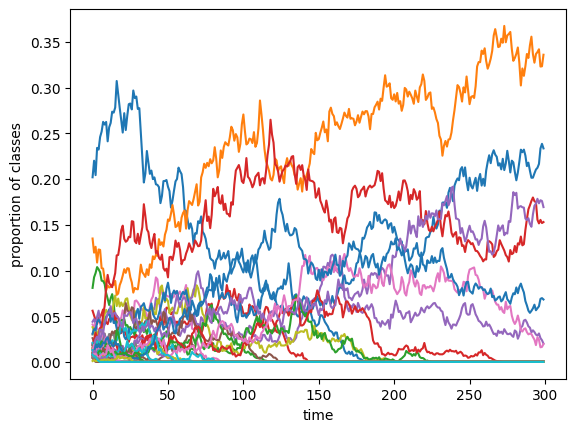

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

T_max = 10**3
n_sites_i = 1000
n_sites_f = 5000
n_class = 40
alpha = 1.0  # Exposant de la loi de puissance (peut être ajusté)

# Générer une distribution de probabilités selon une loi de puissance
ranks = np.arange(1, n_class + 1)
power_law_probs = ranks**(-alpha)
power_law_probs /= power_law_probs.sum()  # Normaliser

# État initial selon une loi de puissance
state = np.random.choice(np.arange(n_class), size=n_sites_i, p=power_law_probs)

# Liste de tailles de population croissantes
pop_size_list = [int(n_sites_i + k * (n_sites_f - n_sites_i) / T_max) for k in range(T_max)]

# Suivi des abondances
spec_counters = []

for t in tqdm(range(T_max)):
    new_gen = np.random.choice(state, replace=True, size=pop_size_list[t])
    state = new_gen
    spec_counters.append(Counter(state))

# Affichage des proportions
ax = plt.subplot()
t_max = 300
for spec_id in range(n_class):
    ax.plot(np.array([c[spec_id] for c in spec_counters])[:t_max] / np.array(pop_size_list)[:t_max])

ax.set_xlabel('time')
ax.set_ylabel('proportion of classes')
plt.show()



In [78]:
spec_counters[500]

Counter({5: 491, 1: 361, 7: 340, 0: 206, 15: 102})

100%|██████████| 1000/1000 [00:00<00:00, 3612.83it/s]


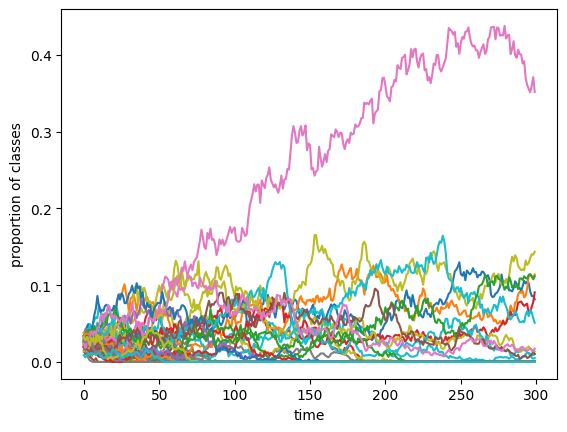

In [6]:
T_max = 10**3
n_sites_i = 1000
n_sites_f = 5000
n_class = 40

state = [np.random.randint(n_class) for k in range(n_sites_i)]

# augmentation affine de la taille de la population de n_site_i à n_site_f en T_max itérations
pop_size_list = [int(n_sites_i + k* (n_sites_f - n_sites_i) / T_max) for k in range(T_max)]

# liste des données d'abondances
spec_counters = []

for t in tqdm(range(T_max)):
    new_gen = np.random.choice(state, replace=True,size=pop_size_list[t])
    state = new_gen
    spec_counters.append(Counter(state))


ax = plt.subplot()
t_max = 300
for spec_id in range(n_class):
    ax.plot(np.array([c[spec_id] for c in spec_counters])[:t_max] / np.array(pop_size_list)[:t_max])

ax.set_xlabel('time')
ax.set_ylabel('proportion of classes')

plt.show()

100%|██████████| 10000/10000 [00:02<00:00, 4079.49it/s]


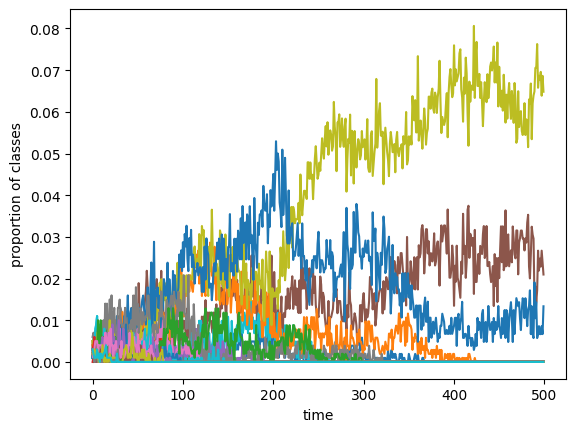

In [102]:
import numpy as np
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paramètres de base
n_class = 40  # nombre de classes/espèces
n_sites_i = 1000  # taille initiale de l’échantillon
n_sites_f = 2000  # taille finale de l’échantillon
T_max = 10**4  # nombre d’itérations (temps max)
archive_rate = 0.1  # taux d'archivage  

state = [np.random.randint(n_class) for k in range(n_sites_i)]

# augmentation affine de la taille de la population de n_site_i à n_site_f en T_max itérations
pop_size_list = [int(n_sites_i + k* (n_sites_f - n_sites_i) / T_max) for k in range(T_max)]

# liste des données d'abondances
spec_counters = []

archive = []

for t in tqdm(range(T_max)):
    new_gen = np.random.choice(state, replace=True,size=pop_size_list[t])
    state = new_gen
    pop_to_archvive = len(state) * archive_rate
    archive.append(Counter(np.random.choice(state, replace=True, size=int(pop_to_archvive))))

    spec_counters.append(Counter(state))


ax = plt.subplot()
t_max = 500
for spec_id in range(n_class):
    ax.plot(np.array([c[spec_id] for c in archive])[:t_max] / np.array(pop_size_list)[:t_max])

ax.set_xlabel('time')
ax.set_ylabel('proportion of classes')
plt.show()

Simulation progress: 100%|██████████| 1000/1000 [00:01<00:00, 580.48it/s]


CSV exported.
Figures exported.


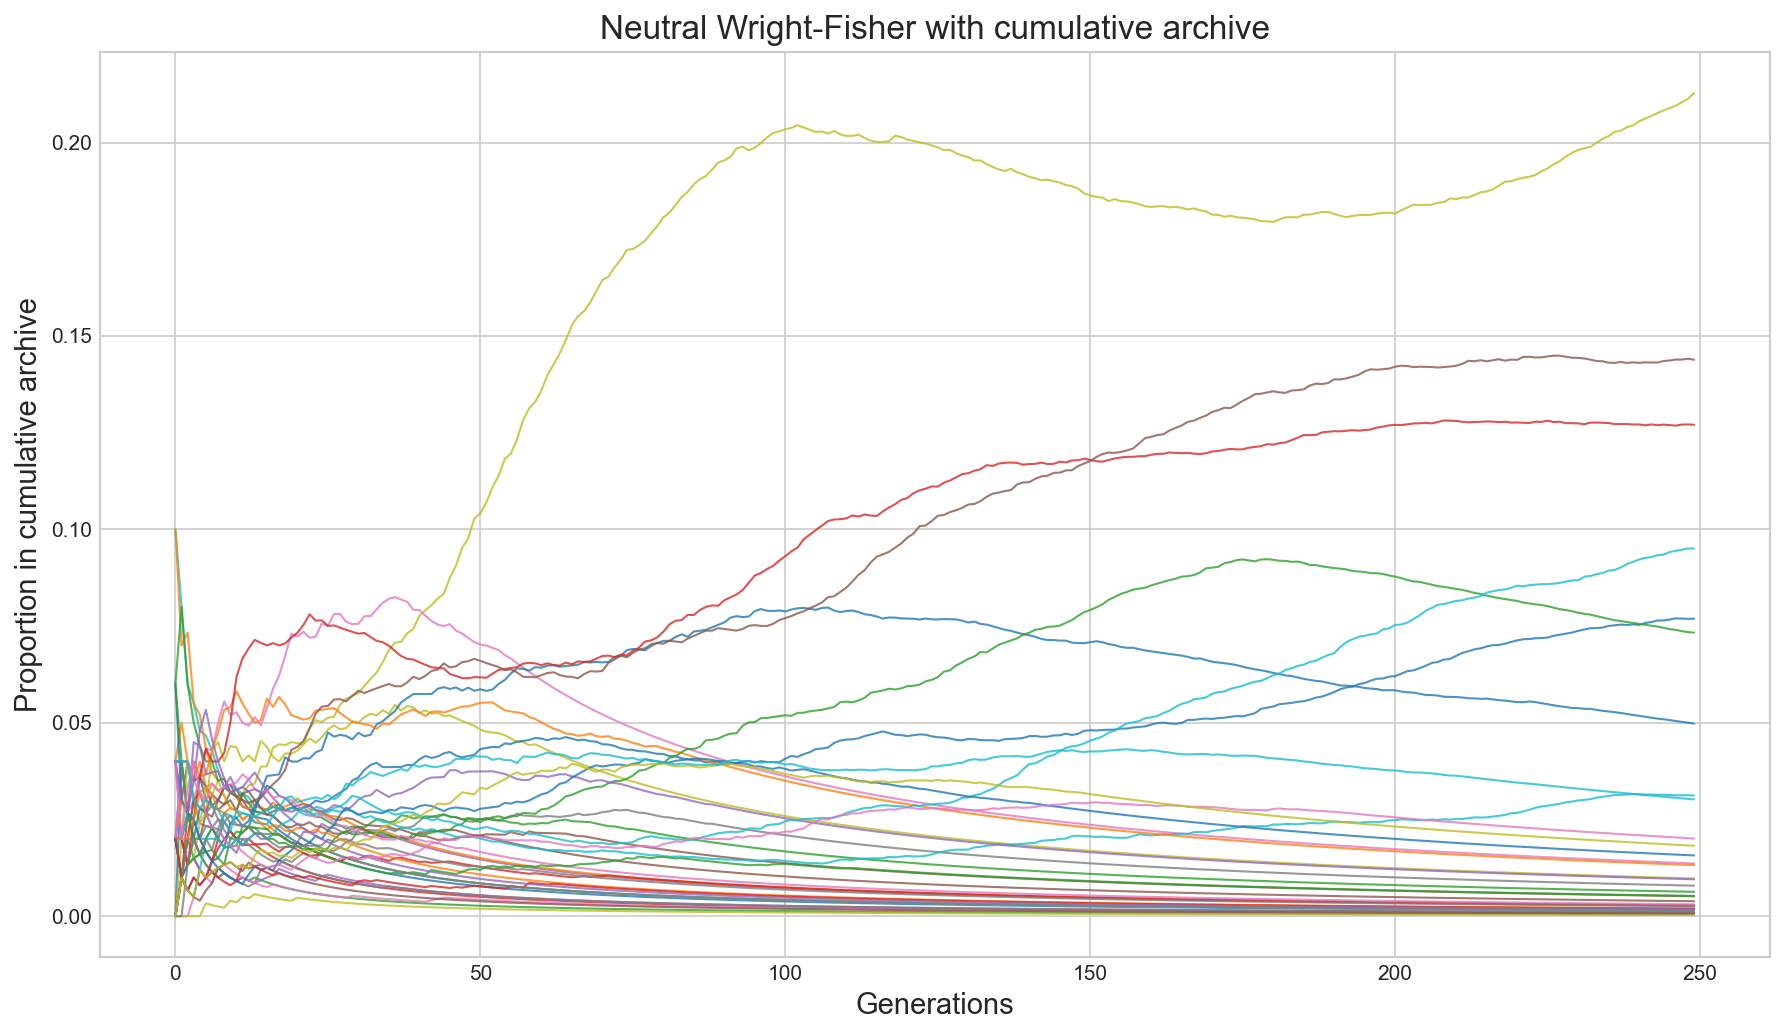

In [5]:
import numpy as np
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


# =========================
# PARAMETERS
# =========================

n_classes = 40              # number of classes/species
n_sites_initial = 1000     # initial active population size
n_sites_final = 2000       # final active population size
T_max = 10**3              # number of generations
archive_rate = 0.05      # archive sampling rate

T_plot = 250  # number of generations to plot

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)


# =========================
# INITIALIZATION
# =========================

# Initial active population
state = np.random.randint(0, n_classes, size=n_sites_initial)

# Linear growth of population size
pop_size_list = [
    int(n_sites_initial + t * (n_sites_final - n_sites_initial) / T_max)
    for t in range(T_max)
]


# Archive storage
cumulative_archive = []

# Proportions over time
cumulative_archive_proportions = []


# =========================
# SIMULATION
# =========================

for t in tqdm(range(T_max), desc="Simulation progress"):

    current_pop_size = pop_size_list[t]

    # Neutral Wright-Fisher reproduction
    state = np.random.choice(
        state,
        replace=True,
        size=current_pop_size
    )

    # Archive sampling
    n_archive = int(len(state) * archive_rate)

    if n_archive > 0:

        archive_sample = np.random.choice(
            state,
            replace=False,
            size=n_archive
        )

        cumulative_archive.extend(archive_sample)


    # Compute proportions
    counts = Counter(cumulative_archive)

    total = len(cumulative_archive)

    proportions = [
        counts[class_id] / total
        for class_id in range(n_classes)
    ]

    cumulative_archive_proportions.append(proportions)



# Convert to numpy array
data_full = np.array(cumulative_archive_proportions).T

T_plot = min(T_plot, data_full.shape[1])

data = data_full[:, :T_plot]


# =========================
# EXPORT CSV
# =========================

df = pd.DataFrame(
    data.T,
    columns=[f"class_{i}" for i in range(n_classes)]
)

df.to_csv(
    output_dir / "archive_proportions.csv",
    index=False
)


print("CSV exported.")



# =========================
# PLOT
# =========================

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(
    figsize=(12, 7),
    dpi=150
)


for class_id in range(n_classes):

    ax.plot(
        data[class_id],
        linewidth=1,
        alpha=0.8
    )


ax.set_xlabel("Generations", fontsize=14)

ax.set_ylabel(
    "Proportion in cumulative archive",
    fontsize=14
)

ax.set_title(
    "Neutral Wright-Fisher with cumulative archive",
    fontsize=16
)


plt.tight_layout()


# =========================
# EXPORT FIGURES
# =========================

plt.savefig(
    output_dir / "archive_proportions.png"
)

plt.savefig(
    output_dir / "archive_proportions.pdf"
)


print("Figures exported.")

plt.show()

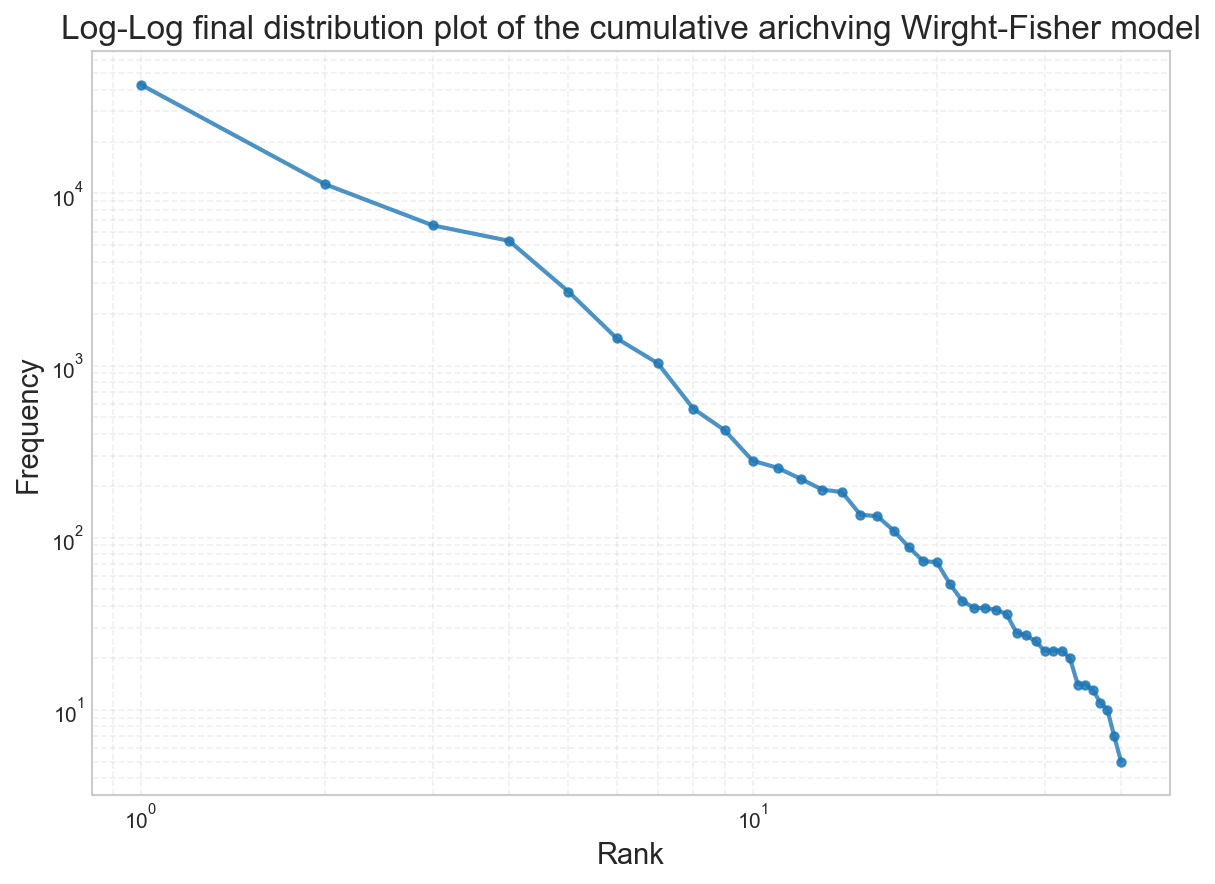

In [9]:
# =========================
# LOG-LOG LINE PLOT
# =========================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


# Count class frequencies in cumulative archive
counts = Counter(cumulative_archive)

frequencies = np.array(list(counts.values()))


# Sort descending (Zipf ranking)
frequencies_sorted = np.sort(frequencies)[::-1]


# Rank axis
ranks = np.arange(1, len(frequencies_sorted) + 1)


# Plot
plt.figure(figsize=(8,6), dpi=150)

plt.loglog(
    ranks,
    frequencies_sorted,
    linewidth=2,
    marker="o",
    markersize=4,
    alpha=0.8
)


plt.xlabel("Rank", fontsize=14)

plt.ylabel("Frequency", fontsize=14)

plt.title("Log-Log final distribution plot of the cumulative arichving Wirght-Fisher model", fontsize=16)

plt.grid(True, which="both", linestyle="--", alpha=0.3)



plt.tight_layout()

plt.show()

NameError: name 'n_class' is not defined

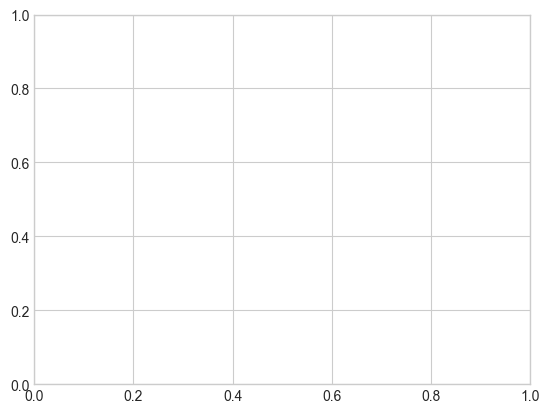

<Figure size 2000x600 with 0 Axes>

In [4]:
ax = plt.subplot()
t_max_plot = 250 # Pour correspondre à l'image fournie

plt.figure(figsize=(20, 6))
data_to_plot = np.zeros((n_class, min(t_max_plot, len(cumulative_archive_proportions))))

for t_idx in range(data_to_plot.shape[1]):
    for spec_id in range(n_class):
        data_to_plot[spec_id, t_idx] = cumulative_archive_proportions[t_idx][spec_id]

for spec_id in range(n_class):
    ax.plot(data_to_plot[spec_id, :])



ax.set_xlabel('generations')
ax.set_ylabel('proportion of cumulative archived classes')
plt.show()

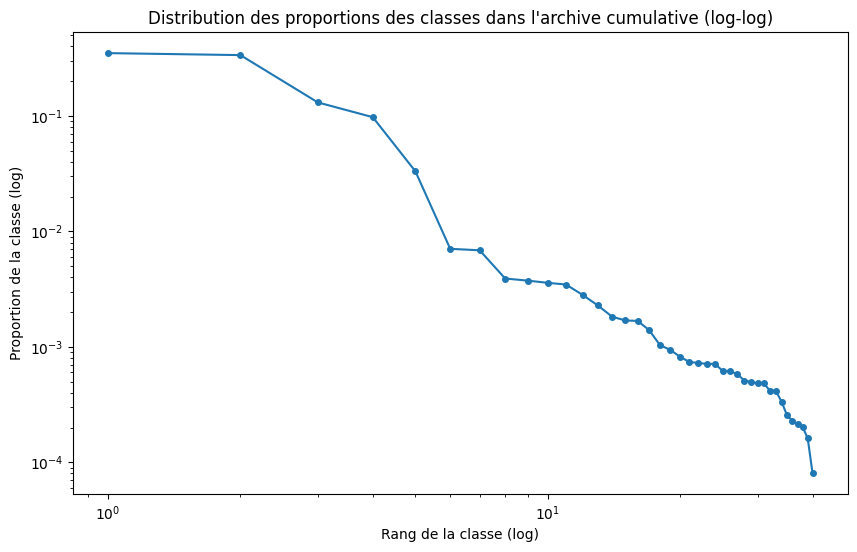

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ... (votre code précédent pour la simulation et la récupération de final_proportions) ...

# 1. Récupérer les proportions finales non nulles
final_proportions = cumulative_archive_proportions[-1]
non_zero_proportions = np.array([prop for prop in final_proportions.values() if prop > 0])

# 2. Trier les proportions par ordre décroissant
# C'est une étape cruciale pour un plot log-log de rang-fréquence
sorted_proportions = np.sort(non_zero_proportions)[::-1]

# 3. Générer les rangs (ou les indices)
ranks = np.arange(1, len(sorted_proportions) + 1)

# 4. Créer le plot log-log
plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_proportions, marker='o', linestyle='-', markersize=4)

plt.xlabel('Rang de la classe (log)')
plt.ylabel('Proportion de la classe (log)')
plt.title('Distribution des proportions des classes dans l\'archive cumulative (log-log)')

plt.show()